In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Logistics- Data- Preprocessing.csv')

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (41652, 52)


In [9]:
print("Rows and Columns:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Rows and Columns: (41652, 52)
Total Missing Values: 0
Duplicate Rows: 0


In [10]:
print(df['Delivery_Days'].describe())

count    41652.000000
mean         3.473567
std          1.645841
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: Delivery_Days, dtype: float64


In [11]:
print("Missing Delivery_Days:", df['Delivery_Days'].isnull().sum())

Missing Delivery_Days: 0


In [12]:
features = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order'
]

target = 'Delivery_Days'

X = df[features]
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (41652, 10)
Target: (41652,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (33321, 10)
Testing data: (8331, 10)


In [22]:
# Remove the feature that is too closely related to the target
features_clean = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order'
]

X = df[features_clean]
y = df['Delivery_Days']

print("New Features:")
print(features_clean)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

New Features:
['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Quantity', 'Order Item Discount', 'Order Item Profit Ratio', 'Sales', 'Order Item Total', 'Order Profit Per Order']

X Shape: (41652, 9)
y Shape: (41652,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (33321, 9)
Testing data: (8331, 9)


**Linear** **Regression**

In [24]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
MAE: 1.1308807199518949
RMSE: 1.3981914796724177
R² Score: 0.2735334132629439


**Random Forest**

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [27]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 1.0430040582335376
RMSE: 1.393565121967624
R² Score: 0.2783329475899199


In [28]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2 Score': [r2_linear, r2_rf]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.130881  1.398191  0.273533
1      Random Forest  1.043004  1.393565  0.278333


In [29]:
if mae_rf < mae_linear and rmse_rf < rmse_linear and r2_rf > r2_linear:
    best_model = rf_model
    print("Best Model: Random Forest")
else:
    best_model = linear_model
    print("Best Model: Linear Regression")

Best Model: Random Forest


In [30]:
importance = pd.DataFrame({
    'Feature': features_clean,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                         Feature  Importance
0  Days for shipment (scheduled)    0.485221
8         Order Profit Per Order    0.107151
1              Benefit per order    0.106849
4            Order Item Discount    0.080452
5        Order Item Profit Ratio    0.074936
7               Order Item Total    0.047910
2             Sales per customer    0.047772
6                          Sales    0.026197
3            Order Item Quantity    0.023512


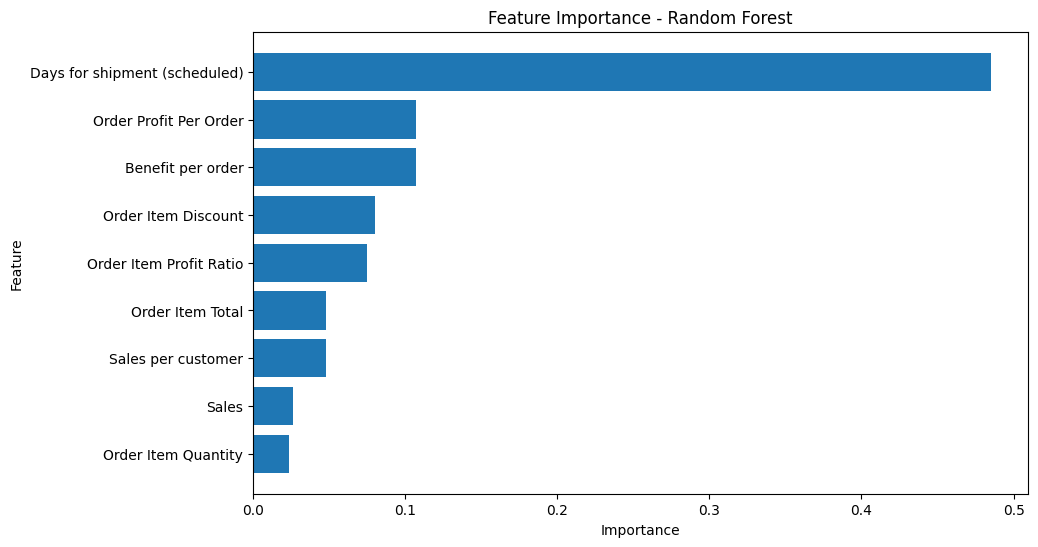

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest')

plt.gca().invert_yaxis()

plt.show()

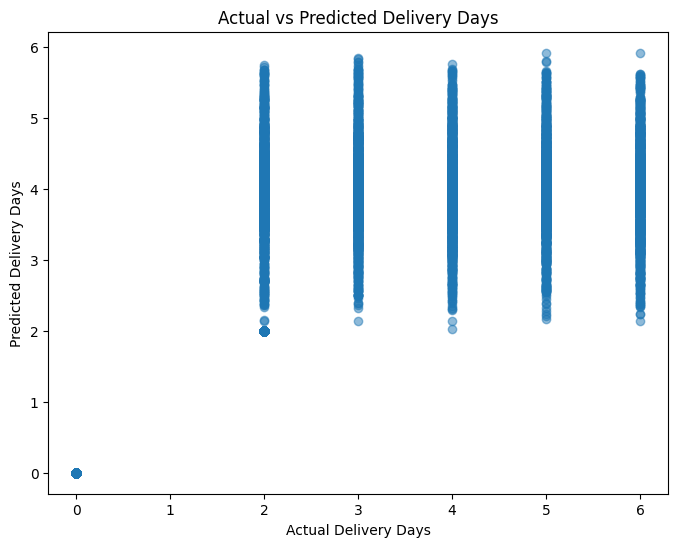

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel('Actual Delivery Days')
plt.ylabel('Predicted Delivery Days')
plt.title('Actual vs Predicted Delivery Days')

plt.show()

In [33]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Actual Delivery Days:", y_test.iloc[0])
print("Predicted Delivery Days:", prediction[0])

Actual Delivery Days: 2.0
Predicted Delivery Days: 3.58


In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("5-Fold Cross-Validation R² Scores:")
print(cv_scores)

print("Mean Cross-Validation R²:", cv_scores.mean())

5-Fold Cross-Validation R² Scores:
[0.08864187 0.2374078  0.34874908 0.44719374 0.22294074]
Mean Cross-Validation R²: 0.2689866456311267


In [35]:
print("Optimization Recommendations:")
print("1. Prioritize shipments with longer scheduled delivery times.")
print("2. Monitor shipments predicted to require additional delivery time.")
print("3. Improve resource allocation for potentially delayed shipments.")
print("4. Review shipping schedules to reduce delivery delays.")
print("5. Use model predictions as an early-warning system for logistics operations.")

Optimization Recommendations:
1. Prioritize shipments with longer scheduled delivery times.
2. Monitor shipments predicted to require additional delivery time.
3. Improve resource allocation for potentially delayed shipments.
4. Review shipping schedules to reduce delivery delays.
5. Use model predictions as an early-warning system for logistics operations.


In [36]:
print("FINAL MODEL SUMMARY")
print("--------------------")
print("Selected Model: Random Forest")
print("MAE:", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R² Score:", round(r2_rf, 4))
print("Number of Features:", len(features_clean))
print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

FINAL MODEL SUMMARY
--------------------
Selected Model: Random Forest
MAE: 1.043
RMSE: 1.3936
R² Score: 0.2783
Number of Features: 9
Training Rows: 33321
Testing Rows: 8331
